# Premier League Match Prediction - Baseline Modeling

## Objective

This notebook trains baseline models to predict the full-time result before kickoff using the engineered feature dataset.

The target is `target_result_encoded`:

- `0` = Home win
- `1` = Draw
- `2` = Away win

The notebook compares a naive baseline, logistic regression, random forest, and LightGBM.

## 1. Modeling Rules

This is a pre-match prediction task, so same-match result columns are excluded from the model inputs.

Excluded leakage/evaluation columns:

- `FTHG`
- `FTAG`
- `FTR`
- `target_result`
- `target_result_encoded`
- `target_home_win`
- `target_draw`
- `target_away_win`

The split is chronological rather than random, so the model is evaluated on future seasons.

## 2. Load Feature Dataset

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("../data/processed/epl_features.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 3800
Columns: 149


,MatchID,Season,Date,Time,HomeTeam,AwayTeam,target_result,target_result_encoded,target_home_win,target_draw,target_away_win,FTHG,FTAG,FTR,home_overall_points_last_5,home_overall_win_last_5,home_overall_draw_last_5,home_overall_loss_last_5,home_overall_goals_for_last_5,home_overall_goals_against_last_5,home_overall_goal_diff_last_5,home_overall_shots_for_last_5,home_overall_shots_against_last_5,home_overall_shot_diff_last_5,home_overall_sot_for_last_5,home_overall_sot_against_last_5,home_overall_sot_diff_last_5,home_overall_corners_for_last_5,home_overall_corners_against_last_5,home_overall_corner_diff_last_5,home_overall_fouls_for_last_5,home_overall_fouls_against_last_5,home_overall_yellow_for_last_5,home_overall_yellow_against_last_5,home_overall_red_for_last_5,home_overall_red_against_last_5,home_overall_points_last_10,home_overall_win_last_10,home_overall_draw_last_10,home_overall_loss_last_10,home_overall_goals_for_last_10,home_overall_goals_against_last_10,home_overall_goal_diff_last_10,home_overall_shots_for_last_10,home_overall_shots_against_last_10,home_overall_shot_diff_last_10,home_overall_sot_for_last_10,home_overall_sot_against_last_10,home_overall_sot_diff_last_10,home_overall_corners_for_last_10,home_overall_corners_against_last_10,home_overall_corner_diff_last_10,home_overall_fouls_for_last_10,home_overall_fouls_against_last_10,home_overall_yellow_for_last_10,home_overall_yellow_against_last_10,home_overall_red_for_last_10,home_overall_red_against_last_10,home_venue_points_last_5,home_venue_win_last_5,home_venue_goals_for_last_5,home_venue_goals_against_last_5,home_venue_goal_diff_last_5,home_venue_shots_for_last_5,home_venue_shots_against_last_5,home_venue_sot_for_last_5,home_venue_sot_against_last_5,home_team_matches_played_before,home_days_since_last_match,home_long_gap_since_last_match,away_overall_points_last_5,away_overall_win_last_5,away_overall_draw_last_5,away_overall_loss_last_5,away_overall_goals_for_last_5,away_overall_goals_against_last_5,away_overall_goal_diff_last_5,away_overall_shots_for_last_5,away_overall_shots_against_last_5,away_overall_shot_diff_last_5,away_overall_sot_for_last_5,away_overall_sot_against_last_5,away_overall_sot_diff_last_5,away_overall_corners_for_last_5,away_overall_corners_against_last_5,away_overall_corner_diff_last_5,away_overall_fouls_for_last_5,away_overall_fouls_against_last_5,away_overall_yellow_for_last_5,away_overall_yellow_against_last_5,away_overall_red_for_last_5,away_overall_red_against_last_5,away_overall_points_last_10,away_overall_win_last_10,away_overall_draw_last_10,away_overall_loss_last_10,away_overall_goals_for_last_10,away_overall_goals_against_last_10,away_overall_goal_diff_last_10,away_overall_shots_for_last_10,away_overall_shots_against_last_10,away_overall_shot_diff_last_10,away_overall_sot_for_last_10,away_overall_sot_against_last_10,away_overall_sot_diff_last_10,away_overall_corners_for_last_10,away_overall_corners_against_last_10,away_overall_corner_diff_last_10,away_overall_fouls_for_last_10,away_overall_fouls_against_last_10,away_overall_yellow_for_last_10,away_overall_yellow_against_last_10,away_overall_red_for_last_10,away_overall_red_against_last_10,away_venue_points_last_5,away_venue_win_last_5,away_venue_goals_for_last_5,away_venue_goals_against_last_5,away_venue_goal_diff_last_5,away_venue_shots_for_last_5,away_venue_shots_against_last_5,away_venue_sot_for_last_5,away_venue_sot_against_last_5,away_team_matches_played_before,away_days_since_last_match,away_long_gap_since_last_match,diff_overall_points_last_5,diff_overall_points_last_10,diff_overall_win_last_5,diff_overall_goal_diff_last_5,diff_overall_goal_diff_last_10,diff_overall_goals_for_last_5,diff_overall_goals_against_last_5,diff_overall_shot_diff_last_5,diff_overall_sot_diff_last_5,diff_overall_corner_diff_last_5,diff_venue_points_last_5,diff_venue_goal_diff_last_5,diff_venue_sot_for_last_5,diff_venue_sot_against_last_5,diff_team_matches_played_before,diff_days_since_last_match,d

## 3. Target Distribution

In [3]:
target_labels = {0: "Home Win", 1: "Draw", 2: "Away Win"}

target_distribution = (
    df["target_result_encoded"]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index=target_labels)
    .mul(100)
    .round(2)
)

target_distribution

target_result_encoded
Home Win    44.63
Draw        23.24
Away Win    32.13
Name: proportion, dtype: float64

## 4. Select Modeling Features

The feature set uses only numeric pre-match engineered features. Identifier columns, team names, target columns, and same-match evaluation columns are excluded.

In [4]:
excluded_cols = [
    "MatchID", "Season", "Date", "Time", "HomeTeam", "AwayTeam",
    "target_result", "target_result_encoded", "target_home_win", "target_draw", "target_away_win",
    "FTHG", "FTAG", "FTR",
]

candidate_features = [col for col in df.columns if col not in excluded_cols]
feature_cols = df[candidate_features].select_dtypes(include=["number", "bool"]).columns.tolist()

X = df[feature_cols]
y = df["target_result_encoded"]

print("Feature count:", len(feature_cols))
print("Target classes:", sorted(y.unique()))

feature_cols[:20]

Feature count: 135
Target classes: [np.int64(0), np.int64(1), np.int64(2)]


['home_overall_points_last_5',
 'home_overall_win_last_5',
 'home_overall_draw_last_5',
 'home_overall_loss_last_5',
 'home_overall_goals_for_last_5',
 'home_overall_goals_against_last_5',
 'home_overall_goal_diff_last_5',
 'home_overall_shots_for_last_5',
 'home_overall_shots_against_last_5',
 'home_overall_shot_diff_last_5',
 'home_overall_sot_for_last_5',
 'home_overall_sot_against_last_5',
 'home_overall_sot_diff_last_5',
 'home_overall_corners_for_last_5',
 'home_overall_corners_against_last_5',
 'home_overall_corner_diff_last_5',
 'home_overall_fouls_for_last_5',
 'home_overall_fouls_against_last_5',
 'home_overall_yellow_for_last_5',
 'home_overall_yellow_against_last_5']

## 5. Chronological Train / Validation / Test Split

The model is trained on older seasons and evaluated on newer seasons.

- Train: 2016_2017 through 2023_2024
- Validation: 2024_2025
- Test: 2025_2026

The validation season is used for model comparison. The test season should be treated as the final holdout.

In [5]:
train_mask = df["Season"] <= "2023_2024"
valid_mask = df["Season"] == "2024_2025"
test_mask = df["Season"] == "2025_2026"

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "start_date": [df.loc[train_mask, "Date"].min(), df.loc[valid_mask, "Date"].min(), df.loc[test_mask, "Date"].min()],
    "end_date": [df.loc[train_mask, "Date"].max(), df.loc[valid_mask, "Date"].max(), df.loc[test_mask, "Date"].max()],
})

split_summary

,split,rows,start_date,end_date
0,train,3040,2016-08-13,2024-05-19
1,validation,380,2024-08-16,2025-05-25
2,test,380,2025-08-15,2026-05-24


## 6. Evaluation Helper

Accuracy is useful, but macro F1 is important because draws are less common than home or away wins. Log loss evaluates the quality of predicted probabilities.

In [6]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    result = {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(y_eval, y_pred, average="macro"),
    }

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)
        result["log_loss"] = log_loss(y_eval, y_proba, labels=[0, 1, 2])
    else:
        result["log_loss"] = np.nan

    return result


def plot_confusion_matrix(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[target_labels[i] for i in [0, 1, 2]],
        yticklabels=[target_labels[i] for i in [0, 1, 2]],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 7. Train Baseline Models

In [7]:
models = {
    "Most Frequent Class": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    "LightGBM": LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        verbose=-1,
    ),
}

validation_results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    validation_results.append(evaluate_model(name, model, X_valid, y_valid))

validation_results = pd.DataFrame(validation_results).sort_values("macro_f1", ascending=False)
validation_results.round(4)

Training Most Frequent Class...
Training Logistic Regression...
Training Random Forest...
Training LightGBM...


,model,accuracy,macro_f1,log_loss
1,Logistic Regression,0.4816,0.4583,1.0322
2,Random Forest,0.5026,0.4066,1.0188
3,LightGBM,0.4684,0.4018,1.0818
0,Most Frequent Class,0.4079,0.1931,21.3416


## 8. Validation Results

The validation season is used to compare model families before looking at the final test season.

In [8]:
validation_results.round(4)

,model,accuracy,macro_f1,log_loss
1,Logistic Regression,0.4816,0.4583,1.0322
2,Random Forest,0.5026,0.4066,1.0188
3,LightGBM,0.4684,0.4018,1.0818
0,Most Frequent Class,0.4079,0.1931,21.3416


### Initial Validation Findings

On the 2024_2025 validation season, the first run produced these main results:

| Model | Accuracy | Macro F1 | Log Loss |
|---|---:|---:|---:|
| Logistic Regression | 0.4816 | 0.4583 | 1.0322 |
| Random Forest | 0.5211 | 0.4196 | 1.0178 |
| LightGBM | 0.4684 | 0.4018 | 1.0818 |
| Most Frequent Class | 0.4079 | 0.1931 | 21.3416 |

Random forest had the highest validation accuracy, but logistic regression had the strongest macro F1. Macro F1 is important here because draws are less common than home or away wins, so the notebook selects the best validation model by macro F1.

## 9. Final Test Evaluation

The best validation model is evaluated on the 2025_2026 holdout season.

In [9]:
best_model_name = validation_results.iloc[0]["model"]
best_model = models[best_model_name]

test_results = pd.DataFrame([
    evaluate_model(best_model_name, best_model, X_test, y_test)
])

print("Best validation model:", best_model_name)

test_results.round(4)

Best validation model: Logistic Regression


,model,accuracy,macro_f1,log_loss
0,Logistic Regression,0.4105,0.4047,1.092


### Initial Test Finding

Using the best validation model by macro F1, logistic regression scored 0.4105 accuracy, 0.4047 macro F1, and 1.0920 log loss on the 2025_2026 test season.

This is a useful first baseline, but the gap between validation and test performance suggests that the next modeling pass should focus on tuning, probability calibration, and comparing against betting-market odds.

## 10. Confusion Matrix

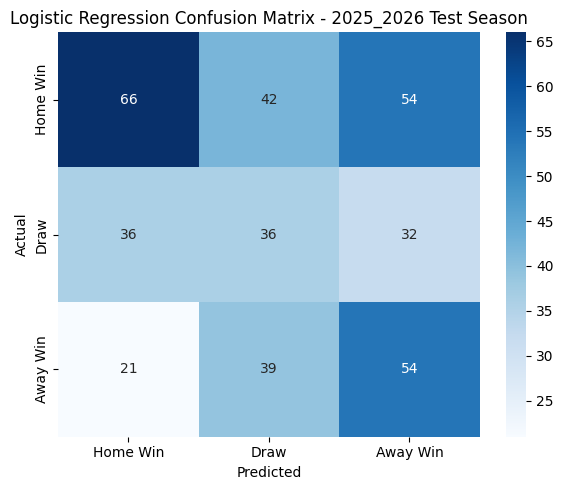

In [10]:
plot_confusion_matrix(
    best_model,
    X_test,
    y_test,
    title=f"{best_model_name} Confusion Matrix - 2025_2026 Test Season",
)

## 11. LightGBM Feature Importance

Feature importance is shown for LightGBM regardless of whether it is the top validation model, because it is useful for interpreting nonlinear tabular signal.

In [11]:
lgbm_model = models["LightGBM"]

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgbm_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
132,referee_total_fouls_last_20,266
133,referee_total_yellow_cards_last_20,212
95,away_overall_fouls_against_last_10,210
130,season_progress,209
125,diff_venue_sot_against_last_5,209
73,away_overall_fouls_against_last_5,202
109,away_team_matches_played_before,196
131,referee_matches_before,195
124,diff_venue_sot_for_last_5,188
17,home_overall_fouls_against_last_5,178


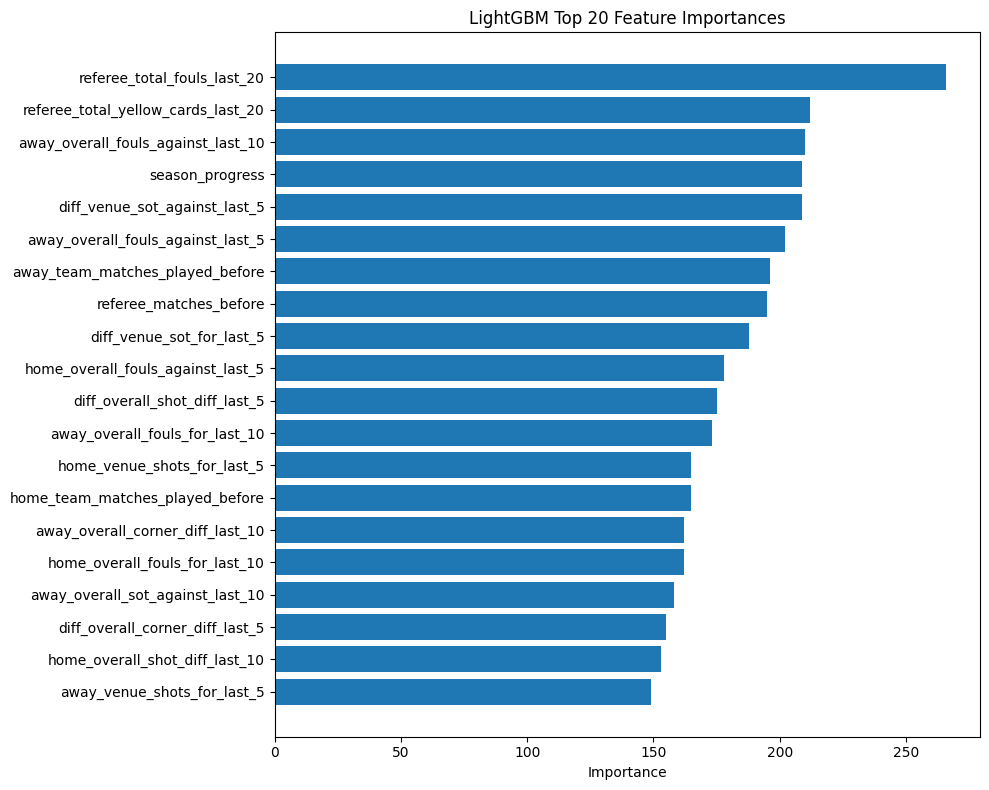

In [12]:
top_importance = importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("LightGBM Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Summary

This notebook establishes baseline model performance using the engineered pre-match features. The next modeling steps are:

- Tune LightGBM hyperparameters using the validation season.
- Compare multiclass modeling against binary tasks such as home-win prediction.
- Add probability calibration if predicted probabilities are used for betting simulations.
- Compare model probabilities against bookmaker odds from the raw data.